## Data cleaning / loading

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('data/responses.csv')
display(data.head())

,#,Are you currently on medicated weight loss?,Where are you currently accessing medicated weight loss?,How would you describe your current thinking about medicated weight loss?,Potential side effects,Unsure if I'm medically eligible,Cost / Affordability,Weight regain after stopping / long-term reliance,Unsure if it will work for me,Judgment from others,...,How would you describe the cost of Juniper compared to the value included in the program?,Is there anything about medicated weight loss that you wish someone had explained clearly or that's still making you hesitate?,Has your financial situation or spending confidence changed in the past 4-6 weeks?,Response Type,Start Date (UTC),Stage Date (UTC),Submit Date (UTC),Network ID,Tags,Ending
0,mcyde7nzt2l2s0aysmcyd71ctqy3doom,No,NaN,I'm curious but haven't seriously considered i...,Potential side effects,NaN,Cost / Affordability,NaN,NaN,NaN,...,"I'm not sure, I don't know enough about what's...",Mainly just the side effects. There is a lot o...,Yes,completed,2026-04-15 01:55:27,NaN,2026-04-15 01:58:15,48a4b7d9d8,NaN,Thanks for completing this typeform\nNow *crea...
1,1vsvz3h3qaeuyt7bj1vsrnmuj89p5ne4,No,NaN,I'm ready to start but haven't taken the step yet,NaN,NaN,NaN,NaN,Unsure if it will work for me,NaN,...,"I'm not sure, I don't know enough about what's...",I would love to loose 5-6 kg \nBut I’m 83 near...,Yes,completed,2026-04-15 01:49:10,NaN,2026-04-15 01:56:03,3d00bfc0c9,NaN,Thanks for completing this typeform\nNow *crea...
2,0g3qmvgnioogq240g3zu4re4ol8wuvdj,Yes,GP / Pharmacist,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,completed,2026-04-15 01:47:56,NaN,2026-04-15 01:48:13,80ea7b0a84,NaN,Thanks for completing this typeform\nNow *crea...
3,c41pcupdcmvxt5c41pcmpeol9jexq9ce,No,NaN,I'm not interested in medicated weight loss,Potential side effects,NaN,Cost / Affordability,Weight regain after stopping / long-term reliance,NaN,NaN,...,"I'm not sure, I don't know enough about what's...",Keeping protein intake up is so important,Yes,completed,2026-04-15 01:47:24,NaN,2026-04-15 01:49:45,6488b2b211,NaN,Thanks for completing this typeform\nNow *crea...
4,n55z984inqv9otv4vn55z9a7nxbh2wnw,No,NaN,I'm not interested in medicated weight loss,NaN,NaN,NaN,NaN,Unsure if it will work for me,NaN,...,NaN,NaN,NaN,partial,2026-04-15 01:45:23,2026-04-15 01:45:39,NaN,74118c8f98,NaN,NaN


## Chart 1 & 2: Medicated Weight Loss Status + Access Source

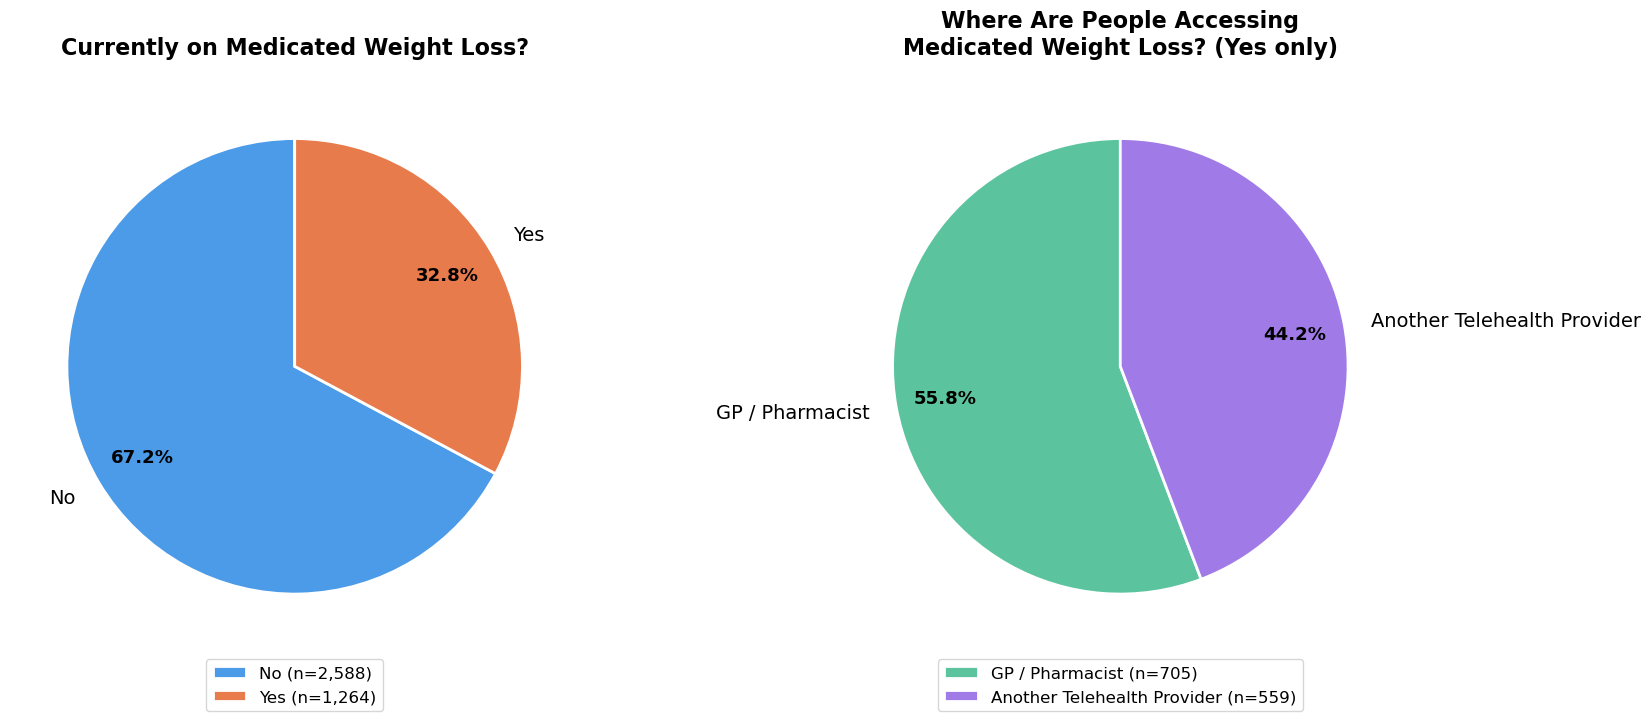


Status breakdown:
Are you currently on medicated weight loss?
No     2588
Yes    1264

Access source (n=1,264 Yes respondents):
Where are you currently accessing medicated weight loss?
GP / Pharmacist                705
Another Telehealth Provider    559


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.subplots_adjust(wspace=0.45)

# --- Chart 1: Currently on medicated weight loss? ---
status_counts = data['Are you currently on medicated weight loss?'].value_counts(dropna=True)
colors_status = ['#4C9BE8', '#E87B4C']

wedges, texts, autotexts = axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_status,
    startangle=90,
    pctdistance=0.78,
    labeldistance=1.12,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 14}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

axes[0].set_title('Currently on Medicated Weight Loss?', fontsize=16, fontweight='bold', pad=20)
axes[0].legend(
    [f'{label} (n={count:,})' for label, count in zip(status_counts.index, status_counts)],
    loc='lower center', bbox_to_anchor=(0.5, -0.12), fontsize=12
)

# --- Chart 2: Access source (Yes respondents only) ---
access_counts = (
    data[data['Are you currently on medicated weight loss?'] == 'Yes']
    ['Where are you currently accessing medicated weight loss?']
    .value_counts(dropna=True)
)
colors_access = ['#5BC49F', '#A07BE8', '#E8D44C']

wedges2, texts2, autotexts2 = axes[1].pie(
    access_counts,
    labels=access_counts.index,
    autopct='%1.1f%%',
    colors=colors_access[:len(access_counts)],
    startangle=90,
    pctdistance=0.78,
    labeldistance=1.12,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 14}
)
for at in autotexts2:
    at.set_fontsize(13)
    at.set_fontweight('bold')

axes[1].set_title('Where Are People Accessing\nMedicated Weight Loss? (Yes only)', fontsize=16, fontweight='bold', pad=20)
axes[1].legend(
    [f'{label} (n={count:,})' for label, count in zip(access_counts.index, access_counts)],
    loc='lower center', bbox_to_anchor=(0.5, -0.12), fontsize=12
)

plt.savefig('charts/chart1_2_weight_loss_status_access.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nStatus breakdown:\n{status_counts.to_string()}")
print(f"\nAccess source (n={access_counts.sum():,} Yes respondents):\n{access_counts.to_string()}")

## Chart 3: Mindset / Thinking Stage (Non-users)

Where are non-users in their decision journey?

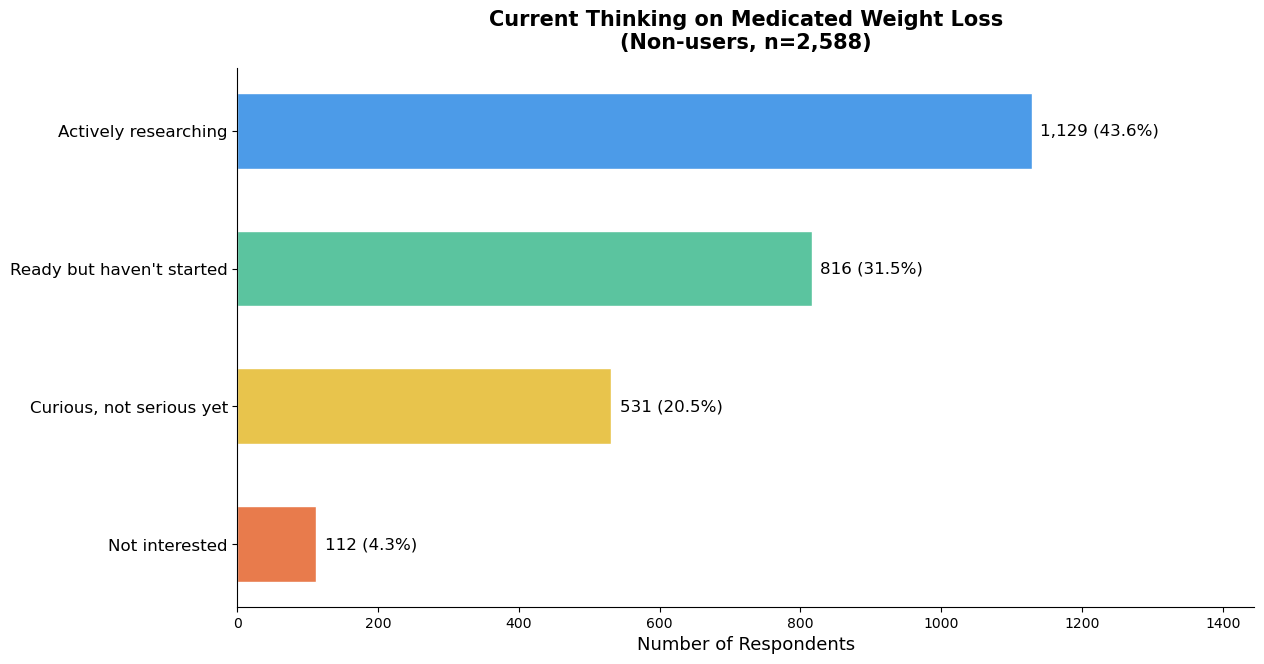

In [98]:
thinking_counts = (
    data[data['Are you currently on medicated weight loss?'] == 'No']
    ['How would you describe your current thinking about medicated weight loss?']
    .value_counts(dropna=True)
)

label_map = {
    "I'm actively researching  and weighing up my options": "Actively researching",
    "I'm ready to start but haven't taken the step yet": "Ready but haven't started",
    "I'm curious but haven't seriously considered it yet": "Curious, not serious yet",
    "I'm not interested in medicated weight loss": "Not interested",
}
thinking_counts.index = thinking_counts.index.map(lambda x: label_map.get(x, x))

colors_thinking = ['#4C9BE8', '#5BC49F', '#E8C44C', '#E87B4C']
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(thinking_counts.index[::-1], thinking_counts.values[::-1],
               color=colors_thinking[::-1], edgecolor='white', height=0.55)

for bar, val in zip(bars, thinking_counts.values[::-1]):
    ax.text(bar.get_width() + 12, bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({val/thinking_counts.sum()*100:.1f}%)', va='center', fontsize=12)

ax.set_xlabel('Number of Respondents', fontsize=13)
ax.set_title('Current Thinking on Medicated Weight Loss\n(Non-users, n={:,})'.format(thinking_counts.sum()),
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlim(0, thinking_counts.max() * 1.28)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart3_thinking_stage.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4: Barriers to Medicated Weight Loss (Multi-select + Biggest Single Barrier)

Two views: all barriers selected vs. the one that matters most.

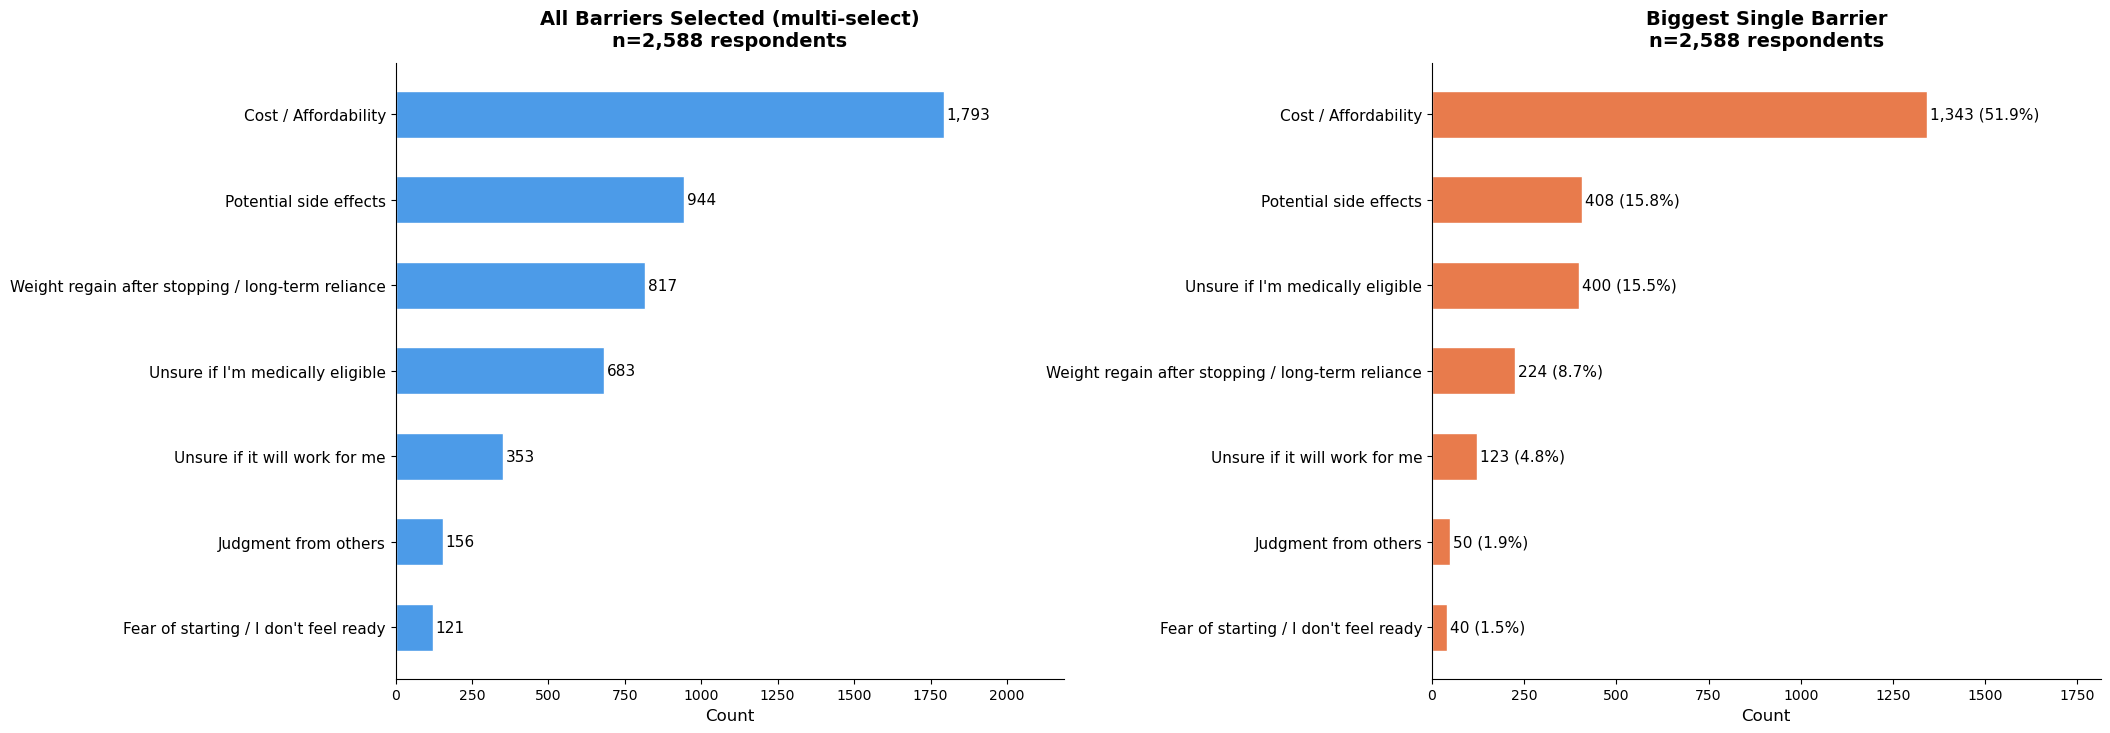

In [99]:
barrier_cols = [
    'Potential side effects',
    "Unsure if I'm medically eligible",
    'Cost / Affordability',
    'Weight regain after stopping / long-term reliance',
    'Unsure if it will work for me',
    'Judgment from others',
    "Fear of starting / I don't feel ready",
]
barrier_counts = pd.Series({col: data[col].notna().sum() for col in barrier_cols}).sort_values()
biggest_barrier = data['Of those, which single barrier feels the biggest right now?'].value_counts(dropna=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.subplots_adjust(wspace=0.55)

# All barriers selected (multi-select)
bars = axes[0].barh(barrier_counts.index, barrier_counts.values, color='#4C9BE8', edgecolor='white', height=0.55)
for bar, val in zip(bars, barrier_counts.values):
    axes[0].text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=11)
axes[0].set_title('All Barriers Selected (multi-select)\nn={:,} respondents'.format(data[barrier_cols].notna().any(axis=1).sum()),
                  fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_xlim(0, barrier_counts.max() * 1.22)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# Biggest single barrier
biggest_barrier_sorted = biggest_barrier.sort_values()
bars2 = axes[1].barh(biggest_barrier_sorted.index, biggest_barrier_sorted.values, color='#E87B4C', edgecolor='white', height=0.55)
for bar, val in zip(bars2, biggest_barrier_sorted.values):
    axes[1].text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
                 f'{val:,} ({val/biggest_barrier.sum()*100:.1f}%)', va='center', fontsize=11)
axes[1].set_title('Biggest Single Barrier\nn={:,} respondents'.format(biggest_barrier.sum()),
                  fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_xlim(0, biggest_barrier_sorted.max() * 1.35)
axes[1].tick_params(axis='y', labelsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

plt.savefig('charts/chart4_barriers.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5: What Matters Most in a Program (Multi-select)

What features/attributes drive consideration?

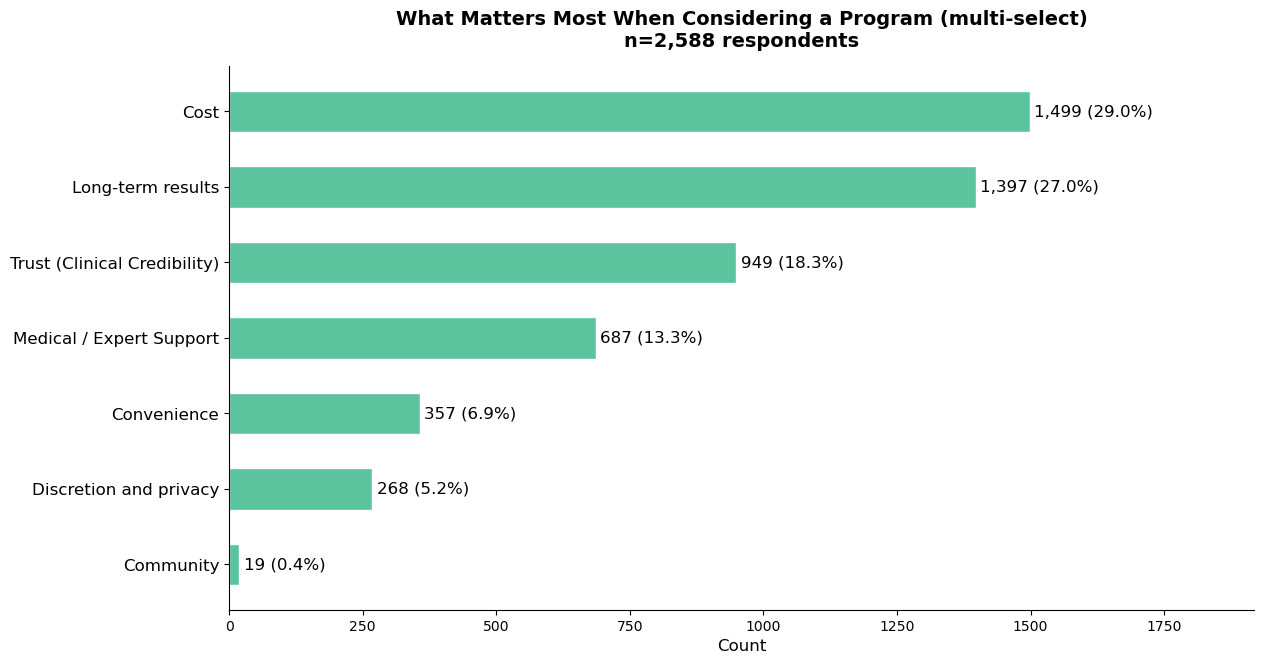

In [100]:
program_cols = [
    'Medical / Expert Support',
    'Trust (Clinical Credibility)',
    'Cost',
    'Long-term results',
    'Community',
    'Convenience',
    'Discretion and privacy',
]
program_counts = pd.Series({col: data[col].notna().sum() for col in program_cols}).sort_values()

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(program_counts.index, program_counts.values, color='#5BC49F', edgecolor='white', height=0.55)
for bar, val in zip(bars, program_counts.values):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({val/program_counts.sum()*100:.1f}%)', va='center', fontsize=12)

ax.set_title("What Matters Most When Considering a Program (multi-select)\nn={:,} respondents".format(
    data[program_cols].notna().any(axis=1).sum()), fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Count', fontsize=12)
ax.set_xlim(0, program_counts.max() * 1.28)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart5_what_matters.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 6: Juniper Cost vs Value Perception

How do non-users perceive Juniper's pricing?

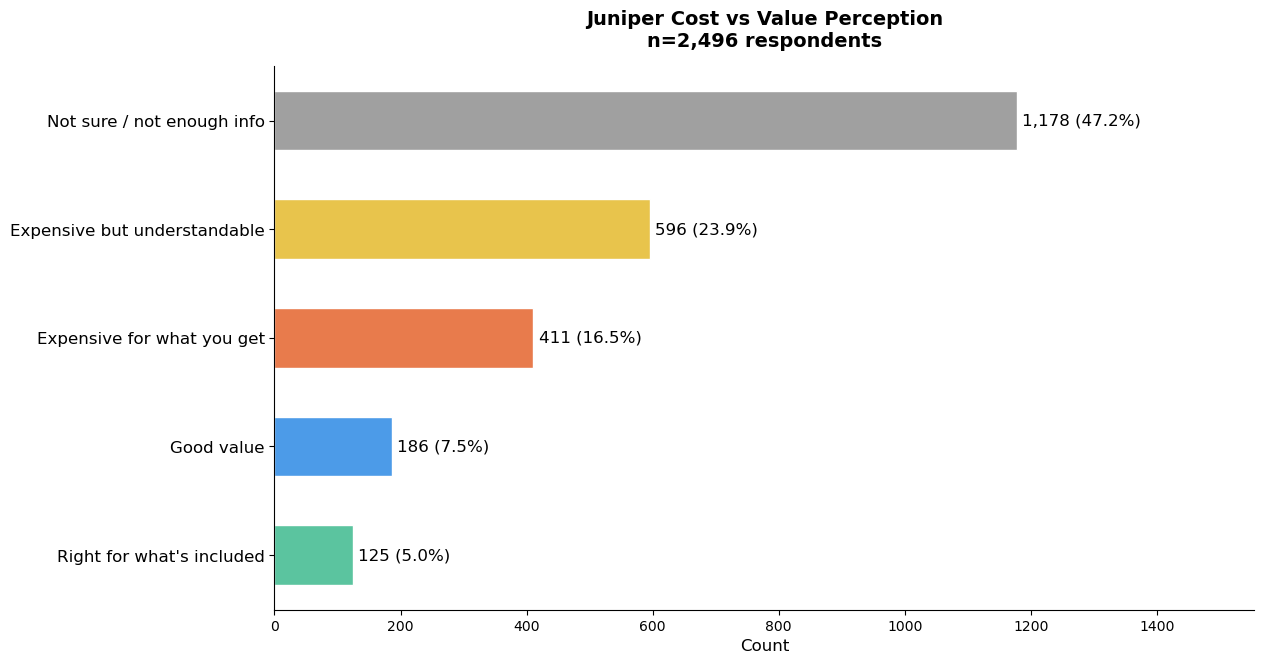

In [101]:
juniper_cost = data['How would you describe the cost of Juniper compared to the value included in the program?'].value_counts(dropna=True)

label_map = {
    "I'm not sure, I don't know enough about what's included": "Not sure / not enough info",
    "It feels expensive but I understand what's included": "Expensive but understandable",
    "It feels expensive for what you get": "Expensive for what you get",
    "It feels like good value for a medical program with ongoing support": "Good value",
    "It feels right for what's included": "Right for what's included",
}
juniper_cost.index = juniper_cost.index.map(lambda x: label_map.get(x, x))
juniper_cost = juniper_cost.sort_values()

color_map = {
    "Not sure / not enough info": "#A0A0A0",
    "Expensive for what you get": "#E87B4C",
    "Expensive but understandable": "#E8C44C",
    "Right for what's included": "#5BC49F",
    "Good value": "#4C9BE8",
}
bar_colors = [color_map.get(label, '#888888') for label in juniper_cost.index]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(juniper_cost.index, juniper_cost.values, color=bar_colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, juniper_cost.values):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({val/juniper_cost.sum()*100:.1f}%)', va='center', fontsize=12)

ax.set_title('Juniper Cost vs Value Perception\nn={:,} respondents'.format(juniper_cost.sum()),
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Count', fontsize=12)
ax.set_xlim(0, juniper_cost.max() * 1.32)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart6_juniper_cost_perception.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 7a: Financial Confidence Change (Past 4–6 Weeks)

Overall — has spending confidence shifted in the last month?

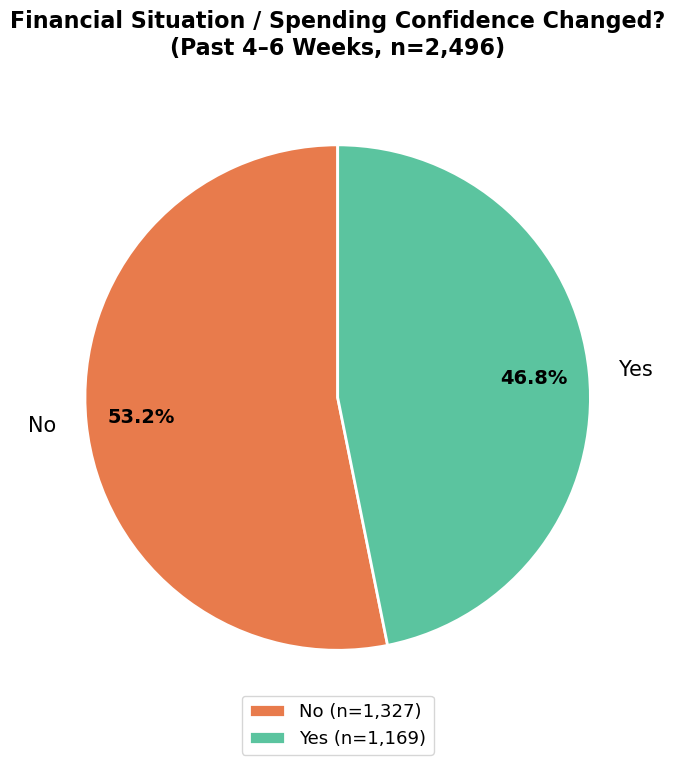

In [102]:
fin_counts = data['Has your financial situation or spending confidence changed in the past 4-6 weeks?'].value_counts(dropna=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fin = ['#E87B4C', '#5BC49F']

wedges, texts, autotexts = ax.pie(
    fin_counts,
    labels=fin_counts.index,
    autopct='%1.1f%%',
    colors=colors_fin,
    startangle=90,
    pctdistance=0.78,
    labeldistance=1.12,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 15}
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')

ax.set_title('Financial Situation / Spending Confidence Changed?\n(Past 4–6 Weeks, n={:,})'.format(fin_counts.sum()),
             fontsize=16, fontweight='bold', pad=20)
ax.legend(
    [f'{label} (n={count:,})' for label, count in zip(fin_counts.index, fin_counts)],
    loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=13
)
plt.tight_layout(pad=2)
plt.savefig('charts/chart7a_financial_change_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 7b: Financial Change by Biggest Barrier

Does financial stress concentrate in the cost-barrier group, or spread evenly?

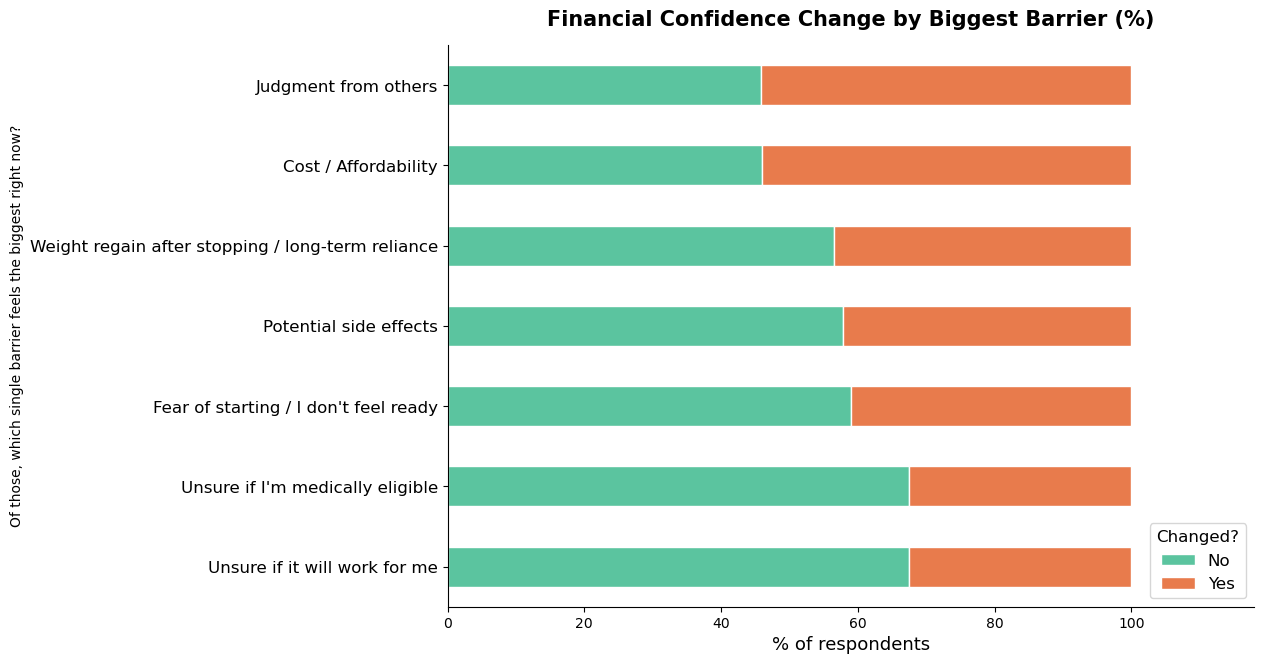

In [103]:
barrier_fin = data.dropna(subset=[
    'Of those, which single barrier feels the biggest right now?',
    'Has your financial situation or spending confidence changed in the past 4-6 weeks?'
])
cross = barrier_fin.groupby(
    ['Of those, which single barrier feels the biggest right now?',
     'Has your financial situation or spending confidence changed in the past 4-6 weeks?']
).size().unstack(fill_value=0)

cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct = cross_pct.sort_values('Yes', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
cross_pct.plot(kind='barh', stacked=True, ax=ax, color=['#5BC49F', '#E87B4C'], edgecolor='white')

ax.set_title('Financial Confidence Change by Biggest Barrier (%)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('% of respondents', fontsize=13)
ax.set_xlim(0, 118)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Changed?', fontsize=12, title_fontsize=12, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart7b_financial_change_by_barrier.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 8: Biggest Barrier by Thinking Stage (Cross-tab Heatmap)

Does the type of barrier shift depending on how far along someone is in their decision?

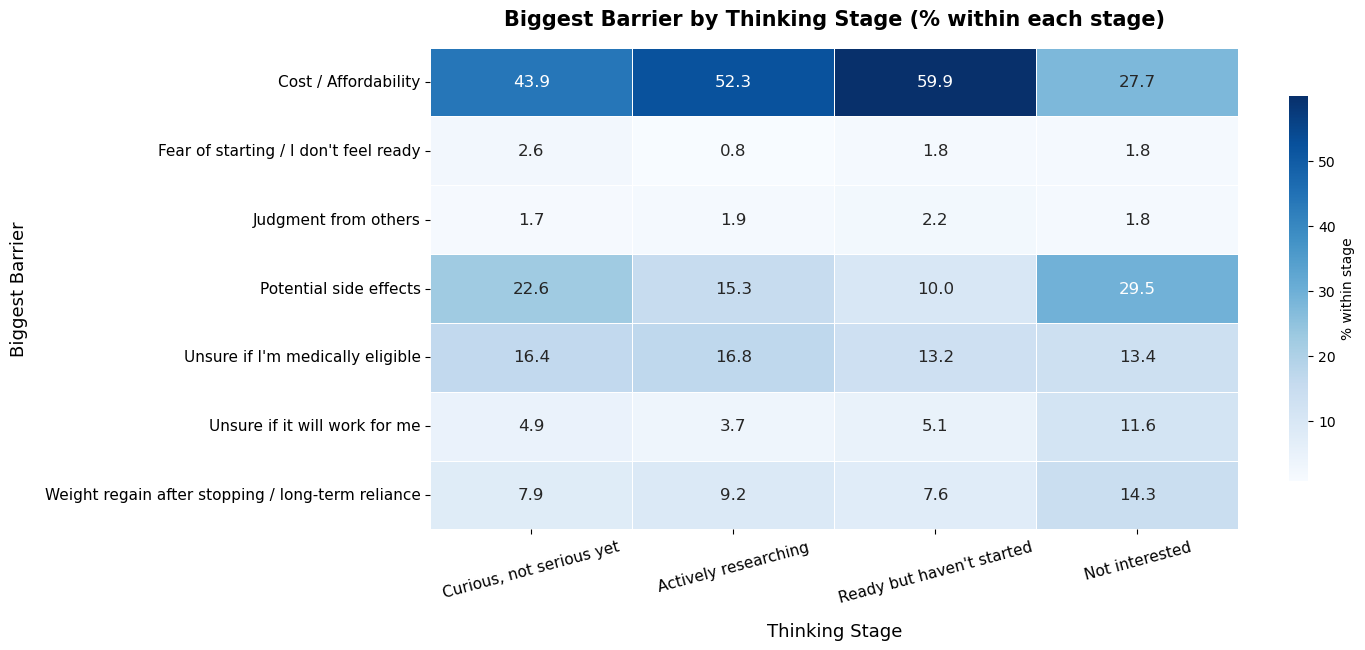

In [104]:
stage_label_map = {
    "I'm actively researching  and weighing up my options": "Actively researching",
    "I'm ready to start but haven't taken the step yet": "Ready but haven't started",
    "I'm curious but haven't seriously considered it yet": "Curious, not serious yet",
    "I'm not interested in medicated weight loss": "Not interested",
}

ct_data = data.dropna(subset=[
    'Of those, which single barrier feels the biggest right now?',
    'How would you describe your current thinking about medicated weight loss?'
]).copy()
ct_data['Stage'] = ct_data['How would you describe your current thinking about medicated weight loss?'].map(stage_label_map)

cross = pd.crosstab(
    ct_data['Of those, which single barrier feels the biggest right now?'],
    ct_data['Stage']
)

stage_order = ["Curious, not serious yet", "Actively researching", "Ready but haven't started", "Not interested"]
cross = cross[[s for s in stage_order if s in cross.columns]]
cross_pct = cross.div(cross.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    cross_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% within stage', 'shrink': 0.8},
    annot_kws={'size': 12}
)
ax.set_title('Biggest Barrier by Thinking Stage (% within each stage)',
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Thinking Stage', fontsize=13, labelpad=12)
ax.set_ylabel('Biggest Barrier', fontsize=13, labelpad=12)
ax.tick_params(axis='x', labelsize=11, rotation=15)
ax.tick_params(axis='y', labelsize=11, rotation=0)
plt.tight_layout(pad=2.5)
plt.savefig('charts/chart8_barrier_by_stage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 9: Audience Funnel

How many respondents are at each stage — from total audience down to currently on medication?

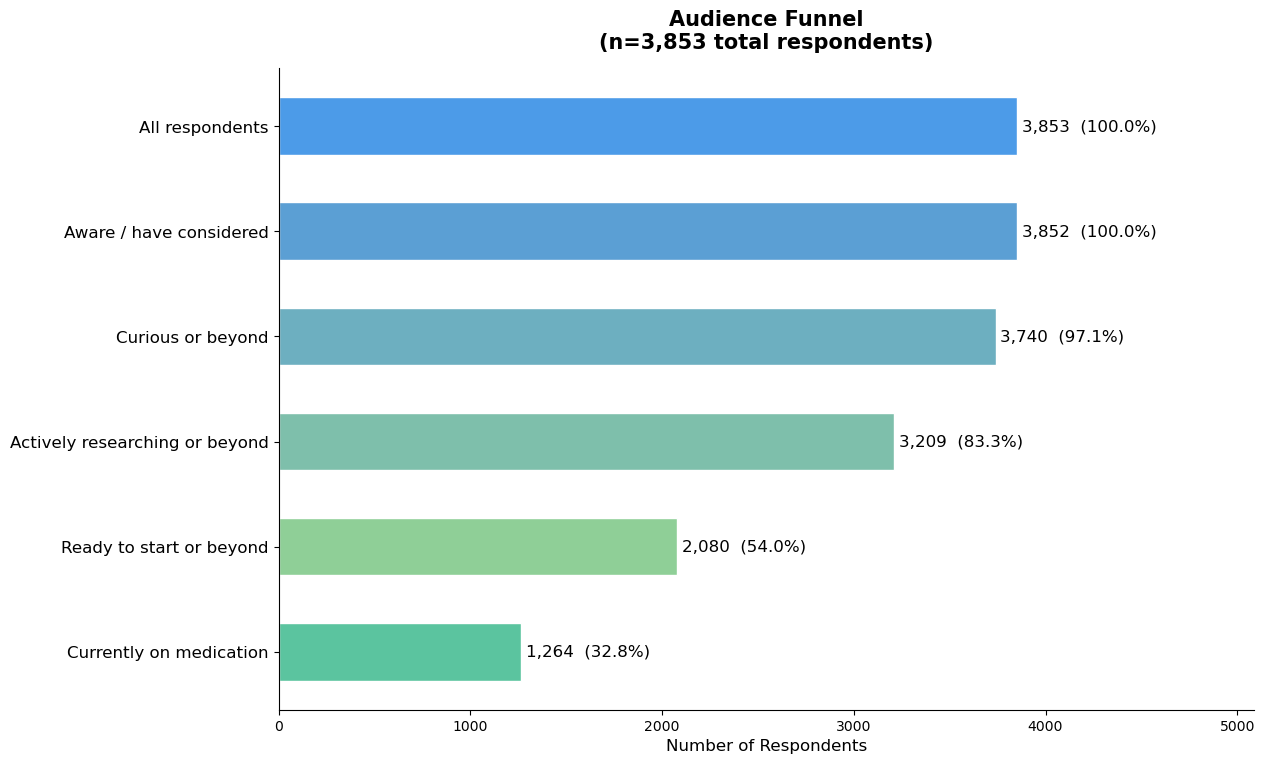

In [105]:
thinking_col = 'How would you describe your current thinking about medicated weight loss?'

total         = len(data)
aware_plus    = data[thinking_col].notna().sum() + (data['Are you currently on medicated weight loss?'] == 'Yes').sum()
considering   = data[thinking_col].isin([
    "I'm curious but haven't seriously considered it yet",
    "I'm actively researching  and weighing up my options",
    "I'm ready to start but haven't taken the step yet",
]).sum() + (data['Are you currently on medicated weight loss?'] == 'Yes').sum()
researching   = data[thinking_col].isin([
    "I'm actively researching  and weighing up my options",
    "I'm ready to start but haven't taken the step yet",
]).sum() + (data['Are you currently on medicated weight loss?'] == 'Yes').sum()
ready         = data[thinking_col].str.contains("ready", na=False).sum() + (data['Are you currently on medicated weight loss?'] == 'Yes').sum()
on_medication = (data['Are you currently on medicated weight loss?'] == 'Yes').sum()

funnel_labels = [
    'All respondents',
    'Aware / have considered',
    'Curious or beyond',
    'Actively researching or beyond',
    'Ready to start or beyond',
    'Currently on medication',
]
funnel_values = [total, aware_plus, considering, researching, ready, on_medication]
funnel_colors = ['#4C9BE8', '#5B9FD4', '#6DAFC0', '#7EBFAB', '#8FCF97', '#5BC49F']

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(funnel_labels[::-1], funnel_values[::-1], color=funnel_colors[::-1],
               edgecolor='white', height=0.55)

for bar, val in zip(bars, funnel_values[::-1]):
    pct = val / total * 100
    ax.text(bar.get_width() + 25, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=12)

ax.set_xlim(0, total * 1.32)
ax.set_xlabel('Number of Respondents', fontsize=12)
ax.set_title('Audience Funnel\n(n={:,} total respondents)'.format(total),
             fontsize=15, fontweight='bold', pad=14)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart9_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 10: Brand Perception — Juniper vs GP

For each attribute, how often is Juniper vs GP selected? Reveals relative brand strength.

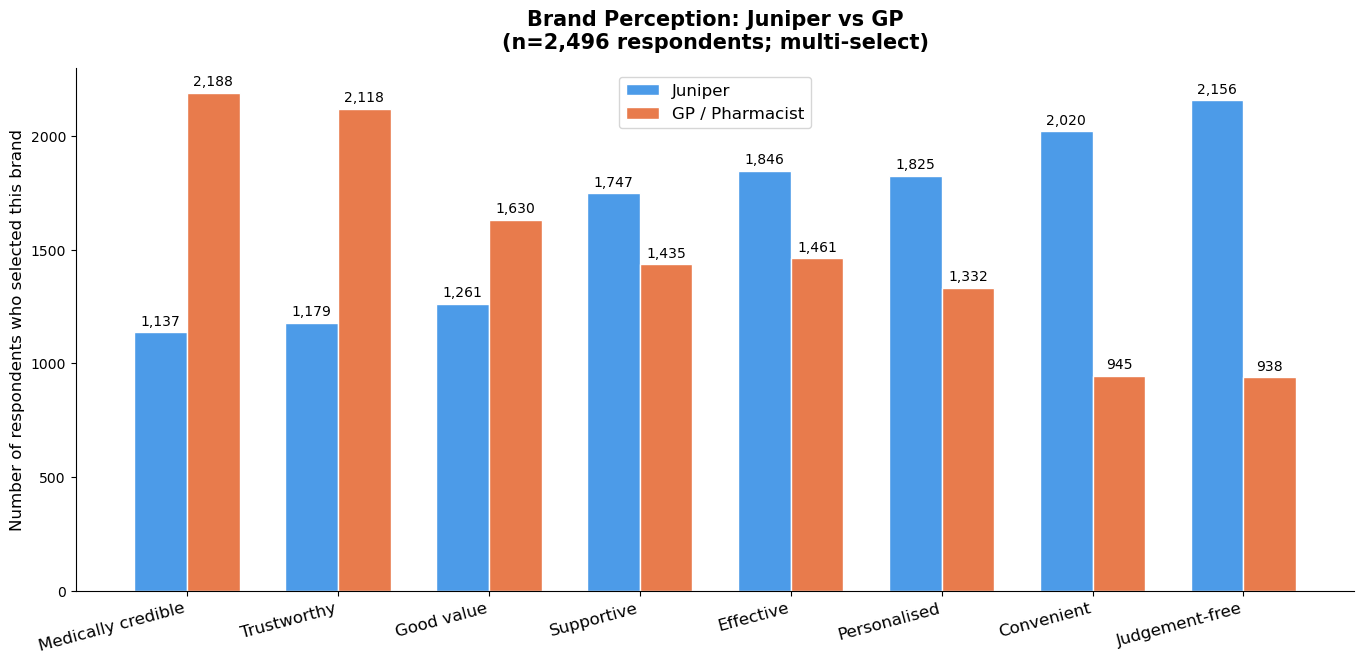

In [106]:
brand_cols = ['Trustworthy', 'Medically credible', 'Effective', 'Supportive',
              'Personalised', 'Judgement-free', 'Good value', 'Convenient']

def count_brand(series, brand):
    return series.dropna().str.contains(brand, regex=False).sum()

juniper_counts = {col: count_brand(data[col], 'Juniper') for col in brand_cols}
gp_counts      = {col: count_brand(data[col], 'My GP')   for col in brand_cols}

brand_df = pd.DataFrame({'Juniper': juniper_counts, 'GP / Pharmacist': gp_counts})
brand_df['diff'] = brand_df['Juniper'] - brand_df['GP / Pharmacist']
brand_df = brand_df.sort_values('diff')

n_respondents = data[brand_cols[0]].notna().sum()

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(brand_df))
width = 0.35

bars_j = ax.bar([i - width/2 for i in x], brand_df['Juniper'],
                width=width, label='Juniper', color='#4C9BE8', edgecolor='white')
bars_g = ax.bar([i + width/2 for i in x], brand_df['GP / Pharmacist'],
                width=width, label='GP / Pharmacist', color='#E87B4C', edgecolor='white')

for bar in list(bars_j) + list(bars_g):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 18,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(list(x))
ax.set_xticklabels(brand_df.index, fontsize=12, rotation=15, ha='right')
ax.set_ylabel('Number of respondents who selected this brand', fontsize=12)
ax.set_title('Brand Perception: Juniper vs GP\n(n={:,} respondents; multi-select)'.format(n_respondents),
             fontsize=15, fontweight='bold', pad=14)
ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart10_brand_perception.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 11: Free-text Themes — What People Wish Was Explained

Keyword frequency from the open-ended hesitation question (n=2,469 responses).

/var/folders/c3/f3r87y696j35jbdd99s0yw7h0000gp/T/ipykernel_39346/1012407506.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = freetext.str.lower().str.contains(pattern, regex=True, na=False).sum()


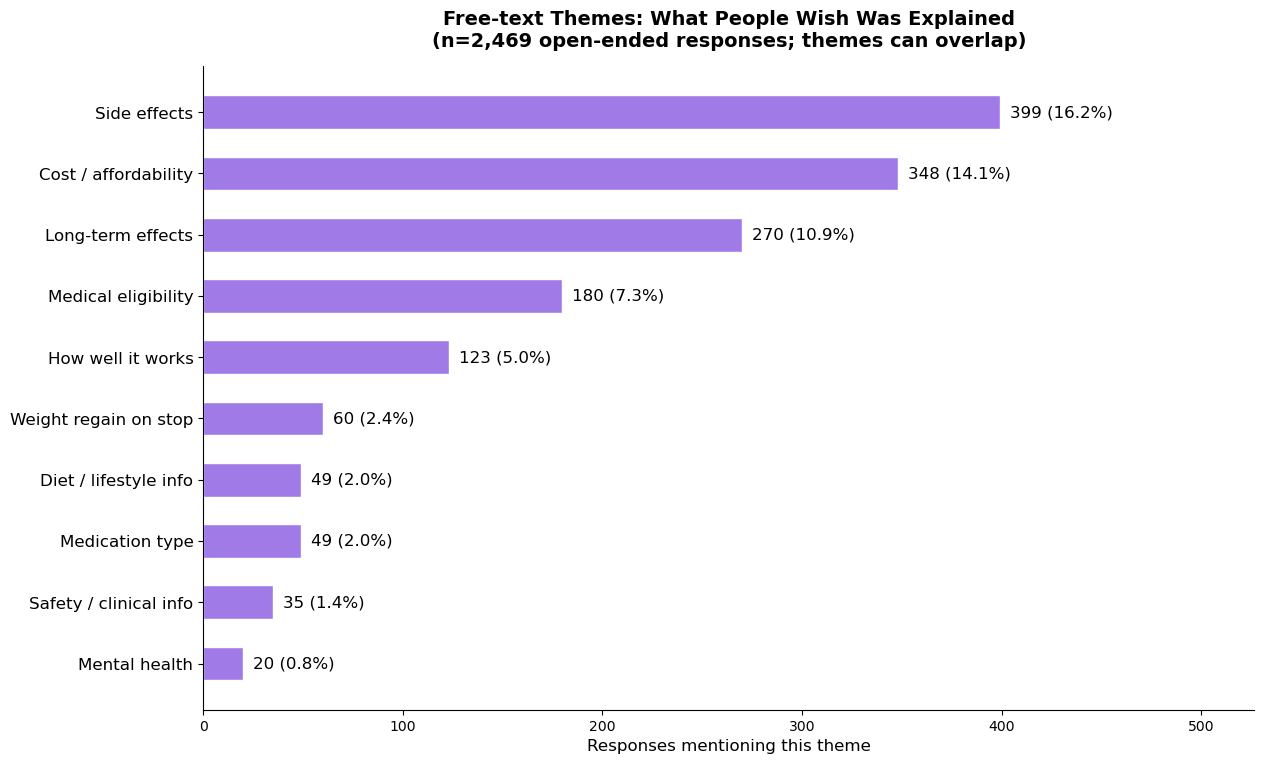


Top 5 example responses mentioning 'Side effects':
  • Mainly just the side effects. There is a lot of talk about the positive effects but not negative
  • what are the side effects long term
  • Just feeling scared about side effects and regaining weight
  • side effects is my main one
  • Feels like the long term side effects are not necessarily clear yet (or perhaps these studies are not well known in the 


In [107]:
import re

freetext_col = 'Is there anything about medicated weight loss that you wish someone had explained clearly or that\'s still making you hesitate?'
freetext = data[freetext_col].dropna()

themes = {
    'Side effects':           r'side effect|nausea|vomit|hair loss|fatigue|tired|sick|muscle',
    'Cost / affordability':   r'cost|price|afford|expensive|cheap',
    'Long-term effects':      r'long.term|long term|after stop|regain|rebound|depend|rely',
    'Medical eligibility':    r'eligible|eligib|qualify|bmi|doctor|gp|prescri',
    'How well it works':      r'\bwork\b|effective|result|success|actual',
    'Safety / clinical info': r'\bsafe\b|clinical|evidence|study|research|proven',
    'Weight regain on stop':  r'weight.*(back|regain|return|rebound)|stop.*weight|regain',
    'Medication type':        r'injection|needle|pill|tablet|ozempic|wegovy|mounjaro|semaglutide|tirzepatide',
    'Diet / lifestyle info':  r'protein|diet|food|exercise|lifestyle|calor',
    'Mental health':          r'mental|anxiety|depress|emotion|mood|psycho',
}

theme_counts = {}
for theme, pattern in themes.items():
    count = freetext.str.lower().str.contains(pattern, regex=True, na=False).sum()
    theme_counts[theme] = count

theme_series = pd.Series(theme_counts).sort_values()

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(theme_series.index, theme_series.values, color='#A07BE8', edgecolor='white', height=0.55)
for bar, val in zip(bars, theme_series.values):
    pct = val / len(freetext) * 100
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=12)

ax.set_xlim(0, theme_series.max() * 1.32)
ax.set_xlabel('Responses mentioning this theme', fontsize=12)
ax.set_title('Free-text Themes: What People Wish Was Explained\n(n={:,} open-ended responses; themes can overlap)'.format(len(freetext)),
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart11_freetext_themes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 example responses mentioning 'Side effects':")
for r in freetext[freetext.str.lower().str.contains(r'side effect', na=False)].head(5):
    print(f'  • {r[:120]}')

---
## Statistical Analysis

---

## Chart 12: Barrier Count Distribution

How many barriers does each non-user select? Reveals whether concern is focused or broad — and shows the platykurtic (flat) distribution shape.

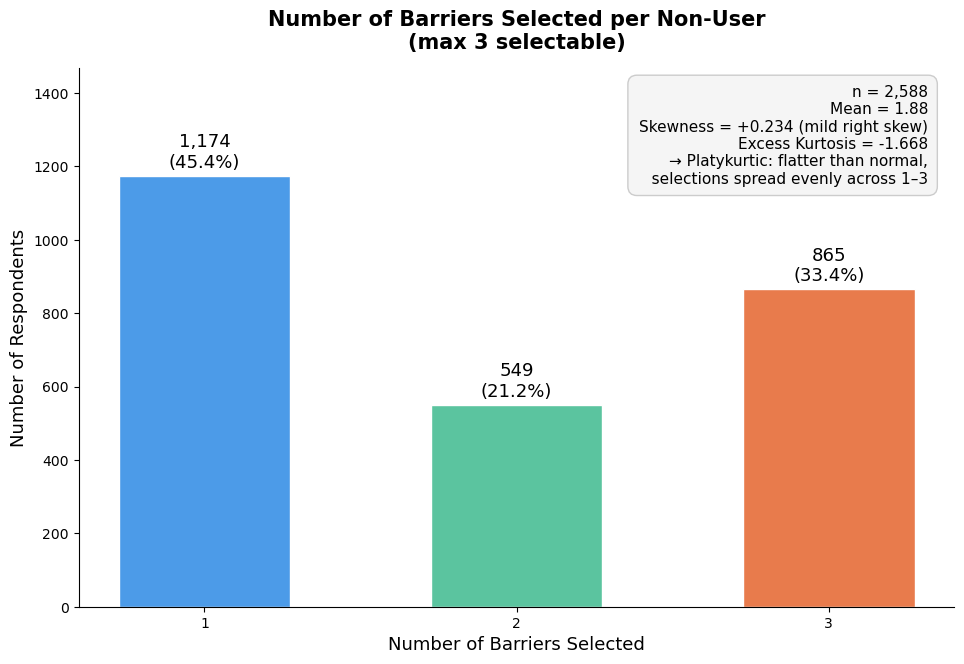

In [108]:
barrier_cols = [
    'Potential side effects',
    "Unsure if I'm medically eligible",
    'Cost / Affordability',
    'Weight regain after stopping / long-term reliance',
    'Unsure if it will work for me',
    'Judgment from others',
    "Fear of starting / I don't feel ready",
]

non_users = data[data['Are you currently on medicated weight loss?'] == 'No'].copy()
non_users['n_barriers'] = non_users[barrier_cols].notna().sum(axis=1)
responders = non_users[non_users['n_barriers'] > 0]['n_barriers']
counts = responders.value_counts().sort_index()

skew  = responders.skew()
kurt  = responders.kurt()
mean  = responders.mean()
total = len(responders)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(counts.index, counts.values, color=['#4C9BE8', '#5BC49F', '#E87B4C'],
              edgecolor='white', width=0.55)

for bar, val in zip(bars, counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 12,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=13)

# Distribution stats annotation box
stats_text = (
    f"n = {total:,}\n"
    f"Mean = {mean:.2f}\n"
    f"Skewness = {skew:+.3f} (mild right skew)\n"
    f"Excess Kurtosis = {kurt:.3f}\n"
    f"→ Platykurtic: flatter than normal,\n"
    f"   selections spread evenly across 1–3"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=11, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#F5F5F5', edgecolor='#CCCCCC'))

ax.set_xlabel('Number of Barriers Selected', fontsize=13)
ax.set_ylabel('Number of Respondents', fontsize=13)
ax.set_title('Number of Barriers Selected per Non-User\n(max 3 selectable)', fontsize=15, fontweight='bold', pad=14)
ax.set_xticks([1, 2, 3])
ax.set_ylim(0, counts.max() * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart12_barrier_count_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 13: Chi-square Effect Sizes (Cramér's V)

Statistical significance (p-value) tells us a relationship exists; Cramér's V tells us how strong it is.

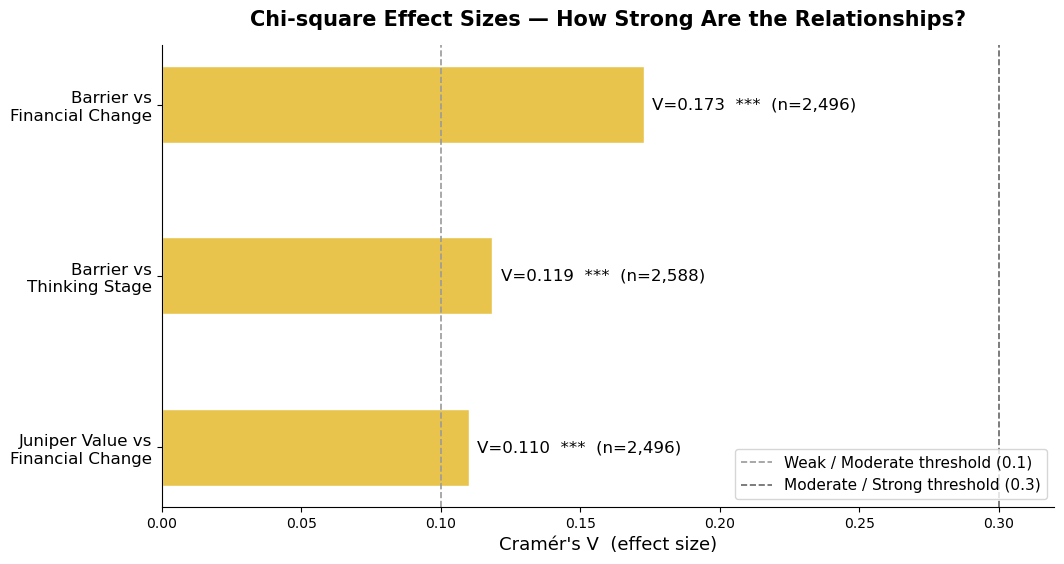


*** p < 0.001  ** p < 0.01  * p < 0.05  ns = not significant
Cramér's V guide: <0.1 weak, 0.1–0.3 moderate, >0.3 strong


In [109]:
from scipy.stats import chi2_contingency

def cramers_v(chi2, n, k, r):
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

chi_tests = []
test_defs = [
    ('Barrier vs\nThinking Stage',
     'Of those, which single barrier feels the biggest right now?',
     'How would you describe your current thinking about medicated weight loss?'),
    ('Barrier vs\nFinancial Change',
     'Of those, which single barrier feels the biggest right now?',
     'Has your financial situation or spending confidence changed in the past 4-6 weeks?'),
    ('Juniper Value vs\nFinancial Change',
     'How would you describe the cost of Juniper compared to the value included in the program?',
     'Has your financial situation or spending confidence changed in the past 4-6 weeks?'),
]

for label, col1, col2 in test_defs:
    df = data.dropna(subset=[col1, col2])
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    cv = cramers_v(chi2, n, ct.shape[0], ct.shape[1])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    chi_tests.append({'Relationship': label, 'chi2': chi2, 'p': p, 'sig': sig,
                      'Cramers_V': cv, 'n': n, 'dof': dof})

chi_df = pd.DataFrame(chi_tests).sort_values('Cramers_V', ascending=True)

# Colour by conventional effect thresholds: weak <0.1, moderate 0.1–0.3, strong >0.3
def v_color(v):
    if v >= 0.3: return '#E87B4C'
    if v >= 0.1: return '#E8C44C'
    return '#4C9BE8'

bar_colors = [v_color(v) for v in chi_df['Cramers_V']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(chi_df['Relationship'], chi_df['Cramers_V'], color=bar_colors,
               edgecolor='white', height=0.45)

for bar, row in zip(bars, chi_df.itertuples()):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"V={row.Cramers_V:.3f}  {row.sig}  (n={row.n:,})",
            va='center', fontsize=12)

# Threshold lines
ax.axvline(0.1, color='#999', linestyle='--', linewidth=1.2, label='Weak / Moderate threshold (0.1)')
ax.axvline(0.3, color='#666', linestyle='--', linewidth=1.2, label='Moderate / Strong threshold (0.3)')

ax.set_xlabel("Cramér's V  (effect size)", fontsize=13)
ax.set_title("Chi-square Effect Sizes — How Strong Are the Relationships?", fontsize=15, fontweight='bold', pad=14)
ax.set_xlim(0, 0.32)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart13_cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n*** p < 0.001  ** p < 0.01  * p < 0.05  ns = not significant")
print("Cramér's V guide: <0.1 weak, 0.1–0.3 moderate, >0.3 strong")

## Chart 14: Barrier Co-occurrence Heatmap

Which barriers get selected together — and which are mutually exclusive? Reveals hidden audience segments.

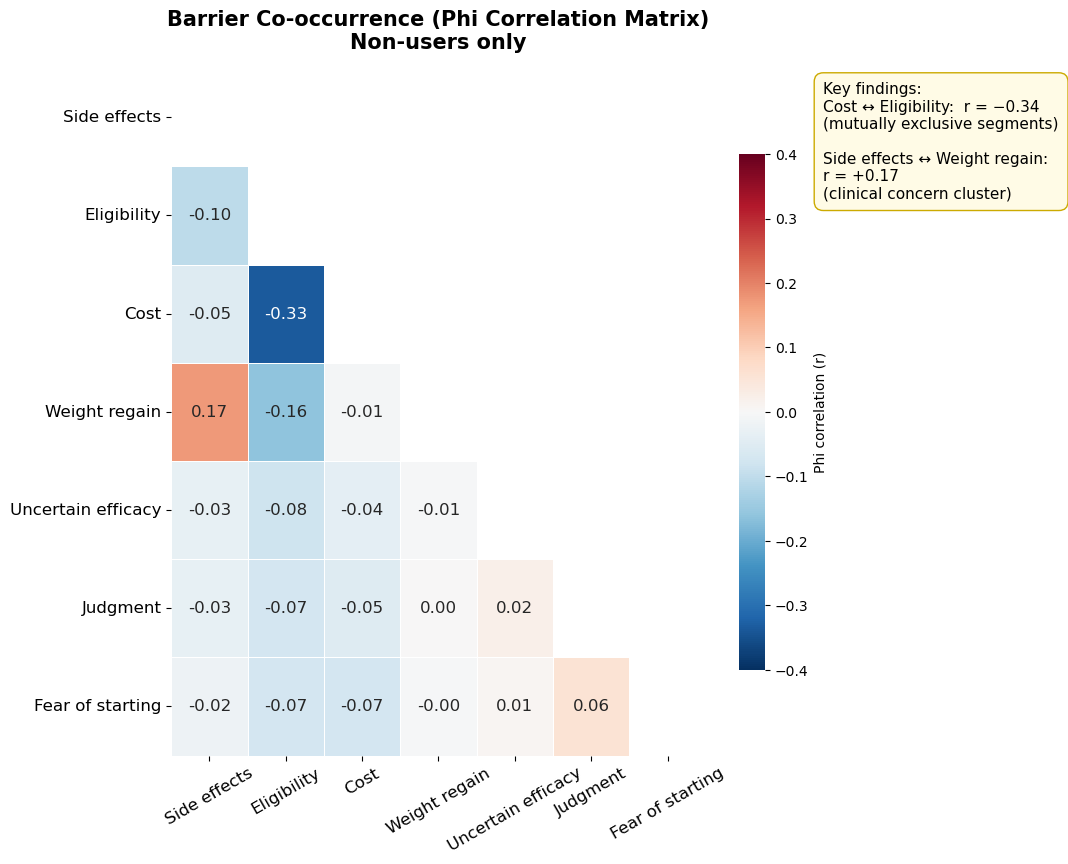

In [110]:
barrier_short = {
    'Potential side effects':                             'Side effects',
    "Unsure if I'm medically eligible":                   'Eligibility',
    'Cost / Affordability':                               'Cost',
    'Weight regain after stopping / long-term reliance':  'Weight regain',
    'Unsure if it will work for me':                      'Uncertain efficacy',
    'Judgment from others':                               'Judgment',
    "Fear of starting / I don't feel ready":              'Fear of starting',
}

non_users = data[data['Are you currently on medicated weight loss?'] == 'No'].copy()
barrier_bin = non_users[list(barrier_short.keys())].notna().astype(int)
barrier_bin.columns = list(barrier_short.values())
corr = barrier_bin.corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-0.4, vmax=0.4,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Phi correlation (r)', 'shrink': 0.75},
    annot_kws={'size': 12}
)
ax.set_title('Barrier Co-occurrence (Phi Correlation Matrix)\nNon-users only', fontsize=15, fontweight='bold', pad=14)
ax.tick_params(axis='x', labelsize=12, rotation=30)
ax.tick_params(axis='y', labelsize=12, rotation=0)

# Annotation callouts
ax.text(1.22, 0.98,
    "Key findings:\n"
    "Cost ↔ Eligibility:  r = −0.34\n"
    "(mutually exclusive segments)\n\n"
    "Side effects ↔ Weight regain:\nr = +0.17\n"
    "(clinical concern cluster)",
    transform=ax.transAxes, fontsize=11, va='top',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFFBE6', edgecolor='#CCAA00'))

plt.tight_layout(pad=2)
plt.savefig('charts/chart14_barrier_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 15: Confidence Intervals for Key Proportions

With n ≈ 2,500–3,800 the CIs are tight — these estimates are reliable.

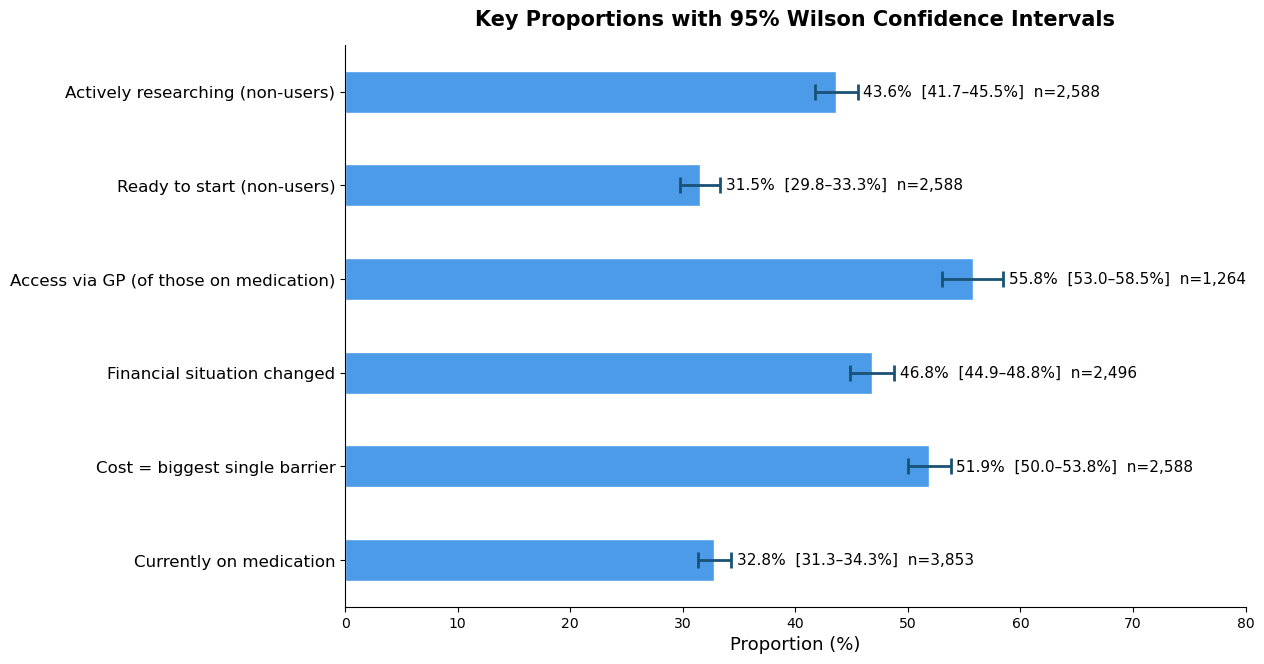

In [111]:
from statsmodels.stats.proportion import proportion_confint

ci_data = [
    ('Currently on medication',
     (data['Are you currently on medicated weight loss?'] == 'Yes').sum(),
     len(data)),
    ('Cost = biggest single barrier',
     (data['Of those, which single barrier feels the biggest right now?'] == 'Cost / Affordability').sum(),
     data['Of those, which single barrier feels the biggest right now?'].notna().sum()),
    ('Financial situation changed',
     (data['Has your financial situation or spending confidence changed in the past 4-6 weeks?'] == 'Yes').sum(),
     data['Has your financial situation or spending confidence changed in the past 4-6 weeks?'].notna().sum()),
    ('Access via GP (of those on medication)',
     (data['Where are you currently accessing medicated weight loss?'] == 'GP / Pharmacist').sum(),
     data['Where are you currently accessing medicated weight loss?'].notna().sum()),
    ('Ready to start (non-users)',
     data['How would you describe your current thinking about medicated weight loss?']
         .str.contains("ready", na=False).sum(),
     data['How would you describe your current thinking about medicated weight loss?'].notna().sum()),
    ('Actively researching (non-users)',
     data['How would you describe your current thinking about medicated weight loss?']
         .str.contains("researching", na=False).sum(),
     data['How would you describe your current thinking about medicated weight loss?'].notna().sum()),
]

labels, centres, lows, highs, ns = [], [], [], [], []
for label, k, n in ci_data:
    lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
    labels.append(label)
    centres.append(k / n * 100)
    lows.append(k / n * 100 - lo * 100)
    highs.append(hi * 100 - k / n * 100)
    ns.append(n)

fig, ax = plt.subplots(figsize=(13, 7))
y_pos = range(len(labels))

ax.barh(y_pos, centres, xerr=[lows, highs],
        color='#4C9BE8', edgecolor='white', height=0.45,
        error_kw=dict(ecolor='#1A5276', elinewidth=2, capsize=6, capthick=2))

for i, (pct, lo, hi, n) in enumerate(zip(centres, lows, highs, ns)):
    ax.text(pct + hi + 0.5, i,
            f"{pct:.1f}%  [{pct-lo:.1f}–{pct+hi:.1f}%]  n={n:,}",
            va='center', fontsize=11)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Proportion (%)', fontsize=13)
ax.set_title('Key Proportions with 95% Wilson Confidence Intervals', fontsize=15, fontweight='bold', pad=14)
ax.set_xlim(0, 80)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart15_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 16a: Audience Segment Distribution

Three distinct concern segments emerge from the barrier co-occurrence analysis.

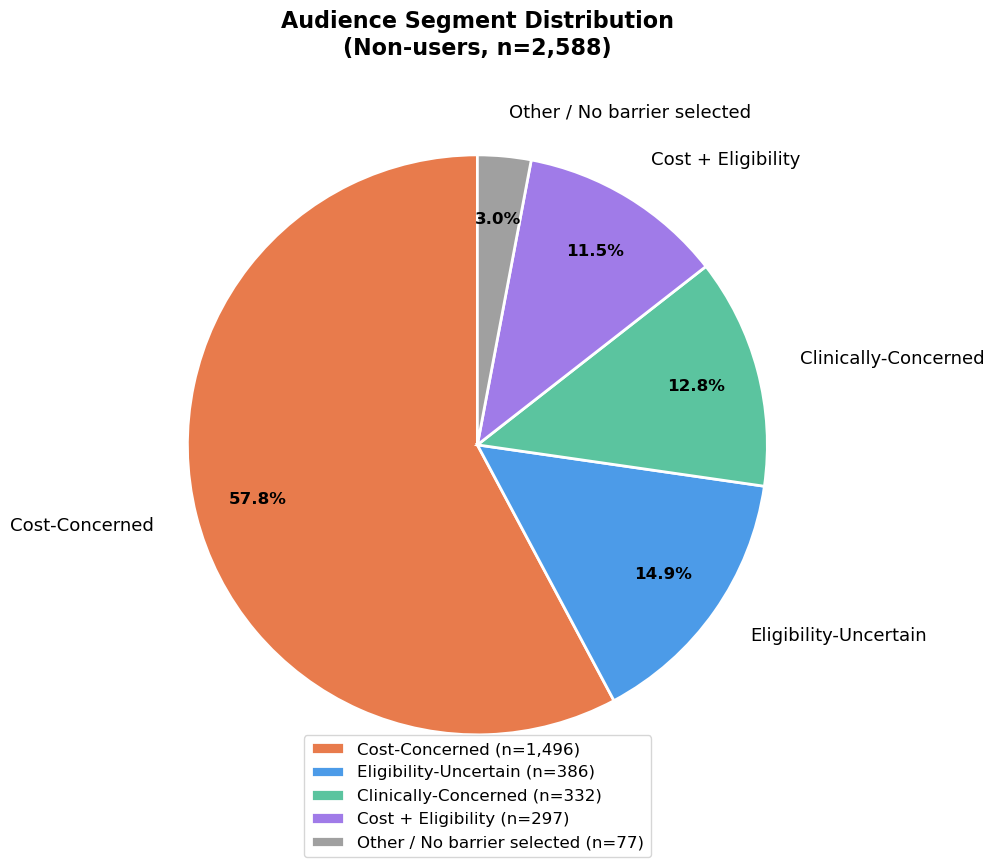

Segment sizes:
  Cost-Concerned: 1,496 (57.8%)
  Eligibility-Uncertain: 386 (14.9%)
  Clinically-Concerned: 332 (12.8%)
  Cost + Eligibility: 297 (11.5%)
  Other / No barrier selected: 77 (3.0%)


In [112]:
non_users = data[data['Are you currently on medicated weight loss?'] == 'No'].copy()

cost_col   = 'Cost / Affordability'
elig_col   = "Unsure if I'm medically eligible"
se_col     = 'Potential side effects'
regain_col = 'Weight regain after stopping / long-term reliance'

def assign_segment(row):
    cost = pd.notna(row[cost_col])
    elig = pd.notna(row[elig_col])
    clin = pd.notna(row[se_col]) or pd.notna(row[regain_col])
    if cost and not elig:              return 'Cost-Concerned'
    if elig and not cost:              return 'Eligibility-Uncertain'
    if clin and not cost and not elig: return 'Clinically-Concerned'
    if cost and elig:                  return 'Cost + Eligibility'
    return 'Other / No barrier selected'

non_users['Segment'] = non_users.apply(assign_segment, axis=1)
seg_counts = non_users['Segment'].value_counts()

seg_colors = {
    'Cost-Concerned':              '#E87B4C',
    'Eligibility-Uncertain':       '#4C9BE8',
    'Clinically-Concerned':        '#5BC49F',
    'Cost + Eligibility':          '#A07BE8',
    'Other / No barrier selected': '#A0A0A0',
}
colors = [seg_colors[s] for s in seg_counts.index]

fig, ax = plt.subplots(figsize=(11, 9))

wedges, texts, autotexts = ax.pie(
    seg_counts,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.78,
    labeldistance=1.15,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')

ax.set_title('Audience Segment Distribution\n(Non-users, n={:,})'.format(len(non_users)),
             fontsize=16, fontweight='bold', pad=20)
ax.legend(
    [f'{s} (n={c:,})' for s, c in zip(seg_counts.index, seg_counts)],
    loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=12
)
plt.tight_layout(pad=2)
plt.savefig('charts/chart16a_audience_segments_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print("Segment sizes:")
for seg, cnt in seg_counts.items():
    print(f"  {seg}: {cnt:,} ({cnt/len(non_users)*100:.1f}%)")


## Chart 16b: Thinking Stage by Audience Segment

Which segments are furthest along the decision funnel?

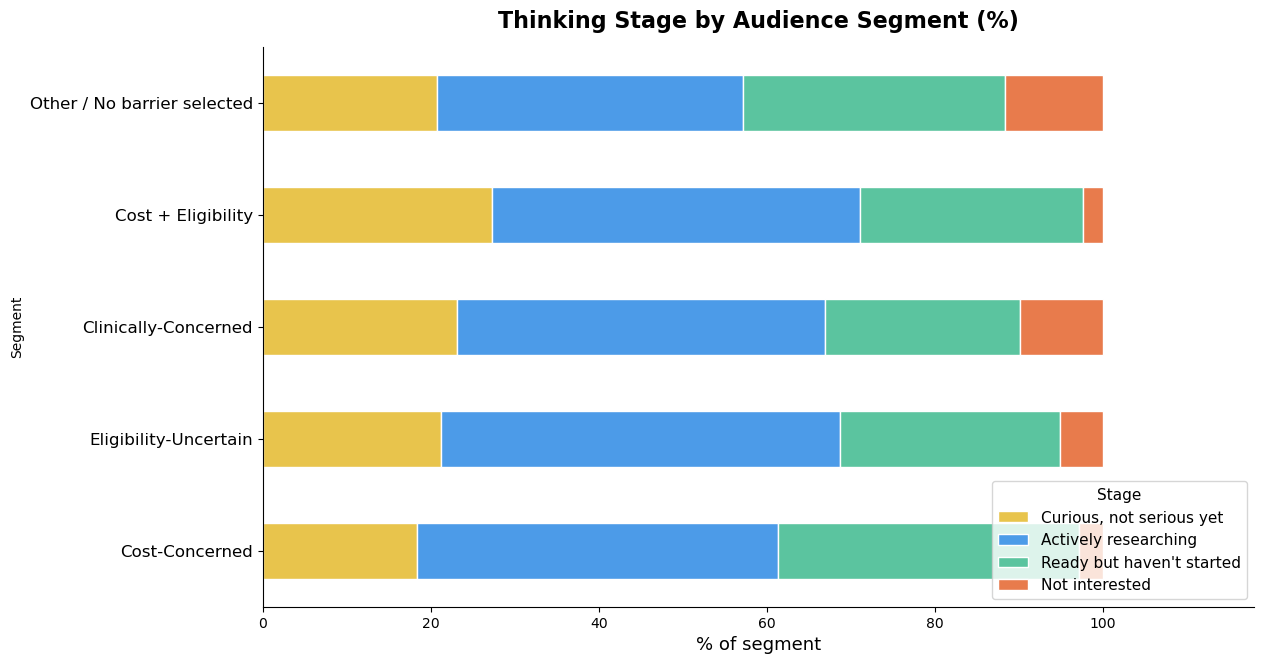

In [113]:
# Reuse seg_counts / non_users['Segment'] computed in Chart 16a
stage_label_map = {
    "I'm actively researching  and weighing up my options": "Actively researching",
    "I'm ready to start but haven't taken the step yet":    "Ready but haven't started",
    "I'm curious but haven't seriously considered it yet":  "Curious, not serious yet",
    "I'm not interested in medicated weight loss":          "Not interested",
}
stage_order = ["Curious, not serious yet", "Actively researching",
               "Ready but haven't started", "Not interested"]

seg_stage = non_users.dropna(
    subset=['How would you describe your current thinking about medicated weight loss?']
).copy()
seg_stage['Stage'] = seg_stage[
    'How would you describe your current thinking about medicated weight loss?'
].map(stage_label_map)

cross = pd.crosstab(seg_stage['Segment'], seg_stage['Stage'])
cross = cross[[s for s in stage_order if s in cross.columns]]
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct = cross_pct.loc[[s for s in seg_counts.index if s in cross_pct.index]]

fig, ax = plt.subplots(figsize=(13, 7))
cross_pct.plot(
    kind='barh', stacked=True, ax=ax,
    color=['#E8C44C', '#4C9BE8', '#5BC49F', '#E87B4C'], edgecolor='white'
)
ax.set_title('Thinking Stage by Audience Segment (%)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('% of segment', fontsize=13)
ax.set_xlim(0, 118)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Stage', fontsize=11, title_fontsize=11, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart16b_audience_segments_stage.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Chart 17: Word Frequency Lexicon Analysis — Free-text Responses

Open-ended question: *"Is there anything about medicated weight loss that you wish someone had explained clearly or that's still making you hesitate?"*
(n=2,469 responses; noise/blank responses filtered out)

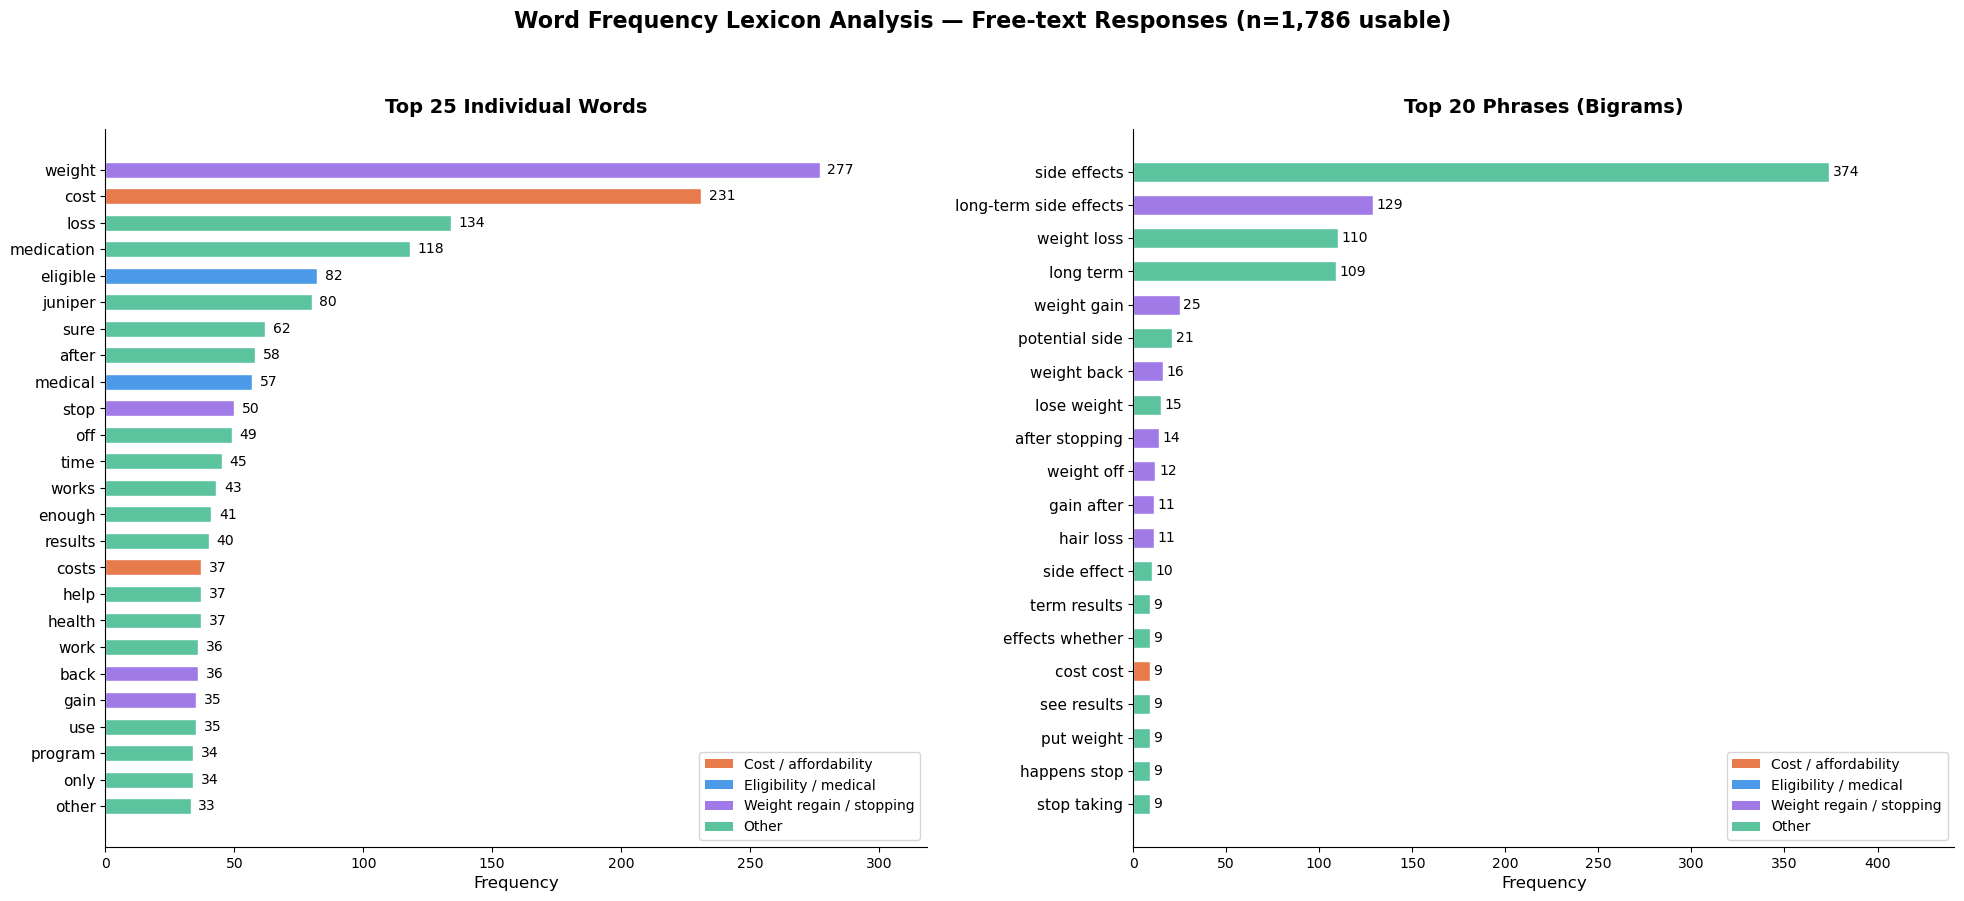

Usable responses analysed: 1,786 of 2,469 total
Total tokens (after stopword removal): 8,987
Unique words: 1,892


In [114]:
import re
from collections import Counter

freetext_col = ("Is there anything about medicated weight loss that you wish "
                "someone had explained clearly or that's still making you hesitate?")
freetext_raw = data[freetext_col].dropna()

# Drop noise/blank responses
noise_responses = {
    'no', 'no.', 'n/a', 'na', 'none', 'nothing', 'nope', 'nil',
    'no thank you', '-', '.', 'no thanks', 'not really', 'nah', 'nil.'
}
freetext_clean = freetext_raw[~freetext_raw.str.strip().str.lower().isin(noise_responses)]
n_responses = len(freetext_clean)

# Stopwords — standard + survey-question artifacts
stopwords = set("""
i me my myself we our ours ourselves you your yours yourself he him his she her hers
they them their theirs it its this that the a an and or but if in on at to for of with
as by from is was are were be been being have has had do does did will would could should
can may might shall very just not no so up about out also all any more some what which
who how when where why than then there here am im ive id ill dont doesnt
didnt wont wouldnt cant couldnt its thats yes like well really feel still get
know think want need into going been make much many even though through been
don lot currently already quite too bit one two
wish explained hesitate someone clearly making
""".split())

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[''`]", '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return [w for w in text.split() if len(w) > 2 and w not in stopwords]

all_tokens = []
for r in freetext_clean:
    all_tokens.extend(tokenize(r))

# Raw bigrams
raw_bigrams = [f'{all_tokens[i]} {all_tokens[i+1]}' for i in range(len(all_tokens)-1)]

# ── Unigrams ──────────────────────────────────────────────────────────────────
# Remove words that are only meaningful as part of a bigram phrase
phrase_fragments = {'side', 'effects', 'long', 'term', 'affects'}
top_words = [(w, c) for w, c in Counter(all_tokens).most_common(50)
             if w not in phrase_fragments][:25]

# ── Bigrams — filter fragments, collapse variants ──────────────────────────────
# Merge "side affects" into "side effects", drop internal n-gram fragments
fragment_pairs = {
    ('term', 'side'), ('effects', 'long'), ('term', 'effects'),
    ('effects', 'side'), ('side', 'affects'), ('effects', 'cost'),
    ('cost', 'side'), ('medicated', 'weight'), ('medical', 'weight'),
    ('cost', 'long'), ('loss', 'medication'), ('term', 'health'),
    ('medication', 'side'), ('effects', 'effects'),
}
bigram_counter = Counter()
for bg in raw_bigrams:
    w1, w2 = bg.split()
    if (w1, w2) in fragment_pairs:
        continue
    if bg == 'side affects':
        bigram_counter['side effects'] += 1
    else:
        bigram_counter[bg] += 1

# Also add "long term side effects" as a consolidated phrase
# (already captured as separate bigrams — re-attribute the trigram count)
lte_count = sum(1 for i in range(len(all_tokens)-2)
                if all_tokens[i]=='long' and all_tokens[i+1]=='term'
                and all_tokens[i+2] in ('side','effects','health','results'))
bigram_counter['long-term side effects'] = lte_count
# Remove the plain "long term" count since it's mostly part of the above
if 'long term' in bigram_counter:
    bigram_counter['long term'] = max(0, bigram_counter['long term'] - lte_count)

top_bigrams = bigram_counter.most_common(20)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.subplots_adjust(wspace=0.5)
fig.suptitle(
    f'Word Frequency Lexicon Analysis — Free-text Responses (n={n_responses:,} usable)',
    fontsize=16, fontweight='bold', y=1.01
)

# ── Left: Top 25 words ──
words, wcounts = zip(*top_words)
word_colors = ['#E87B4C' if w in ('cost','costs','expensive','afford','price') else
               '#4C9BE8' if w in ('eligible','eligibility','medical','doctor','gp','eligible') else
               '#A07BE8' if w in ('weight','gain','regain','stop','stopping','back') else
               '#5BC49F' for w in words]

axes[0].barh(list(words)[::-1], list(wcounts)[::-1],
             color=word_colors[::-1], edgecolor='white', height=0.6)
for i, (w, c) in enumerate(zip(reversed(words), reversed(wcounts))):
    axes[0].text(c + 3, i, str(c), va='center', fontsize=10)

axes[0].set_title('Top 25 Individual Words', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].set_xlim(0, max(wcounts) * 1.15)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# Colour legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#E87B4C', label='Cost / affordability'),
    Patch(facecolor='#4C9BE8', label='Eligibility / medical'),
    Patch(facecolor='#A07BE8', label='Weight regain / stopping'),
    Patch(facecolor='#5BC49F', label='Other'),
]
axes[0].legend(handles=legend_els, fontsize=10, loc='lower right')

# ── Right: Top 20 phrases (bigrams) ──
phrases, pcounts = zip(*top_bigrams)
phrase_colors = [
    '#E87B4C' if any(k in p for k in ('cost','afford','expensive','price')) else
    '#4C9BE8' if any(k in p for k in ('eligible','medical','doctor')) else
    '#A07BE8' if any(k in p for k in ('long-term','weight gain','weight back',
                                       'weight off','gain after','after stopping','hair')) else
    '#5BC49F' for p in phrases
]

axes[1].barh(list(phrases)[::-1], list(pcounts)[::-1],
             color=phrase_colors[::-1], edgecolor='white', height=0.6)
for i, (p, c) in enumerate(zip(reversed(phrases), reversed(pcounts))):
    axes[1].text(c + 2, i, str(c), va='center', fontsize=10)

axes[1].set_title('Top 20 Phrases (Bigrams)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_xlim(0, max(pcounts) * 1.18)
axes[1].tick_params(axis='y', labelsize=11)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(handles=legend_els, fontsize=10, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('charts/chart17_lexicon_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Usable responses analysed: {n_responses:,} of {len(freetext_raw):,} total")
print(f"Total tokens (after stopword removal): {len(all_tokens):,}")
print(f"Unique words: {len(set(all_tokens)):,}")